# Get started

In [ ]:
import marimo as mo

Let's start with a basic example. The task is **text classification**. In particular, we want to find out whether some social media comments contain hate speech or not.

We define some examples to begin with:

In [ ]:
from lmeh.datatypes import Example

dataset = [
    Example(inputs={"comment": "I think you are pretty ugly"}, reference=True),
    Example(inputs={"comment": "I love raspberry muffins"}, reference=False),
    Example(inputs={"comment": "What is wrong with ur face bro?"}, reference=True),
    Example(inputs={"comment": "Paris is the capital of Italy"}, reference=False),
    Example(inputs={"comment": "a cagar al campo chaval"}, reference=True),
]

Now, we define the target function that performs the classification. Its outputs are the ones we will evaluate.

The function must adhere to the `TargetFunction` protocol: take **some inputs** and the **LM config**, then return a `TargetOutput`.

In [ ]:
from lmdk import complete, render_template

from lmeh.datatypes import TargetConfig, TargetOutput

def detect_hate(inputs: dict[str, str], config: TargetConfig) -> TargetOutput:
    prompt = render_template(template=config.prompt_template, COMMENT=inputs["comment"])
    response = complete(
        model=config.model,
        generation_kwargs=config.generation_kwargs,
        prompt=prompt,
        return_request=True,
        output_schema=config.output_schema,
    )
    return TargetOutput.passthrough(response=response)

Now, lets define the config under test. These are the moving parts that we want to evaluate and optimize: the model, prompt template, output schema, generation kwargs, etc.

In [ ]:
from pydantic import BaseModel, Field

class Output(BaseModel):
    is_hate: bool
    reason: str = Field(description="The brief reason why the comment is hate speech or not")

config = TargetConfig(
    model="mistral:mistral-small-latest",
    generation_kwargs={"temperature": 0.7},
    prompt_template="Do you think the comment '{{ COMMENT }}' is hate speech?",
    output_schema=Output,
)

With these ingredients, we can already run a trial: execute the target function with one of the examples and the config under test.

In [ ]:
from lmeh.execution import run_trial

trial = run_trial(target=detect_hate, example=dataset[0], config=config)

print(trial.result.output)

is_hate=True reason="The comment directly attacks someone's appearance in a derogatory manner, which can be considered hate speech as it dehumanizes and demeans the individual based on physical attributes."


Now that our trial run successfully, we can jump into the quality measurements.

Let's define a silly metric that simply compares the output from the function for the given example against the reference (our truth value).

For this, we do not need to use a `LLMJudgeScorer`. A deterministic scorer is more than enough. It must follow the `ProgrammaticScorer` protocol. We define the possible values using the `Ordinal` scale.

In [ ]:
from lmeh.datatypes import Metric, Ordinal, Score

def is_correct(output: bool, example: Example) -> Score:
    raw_score = output.is_hate == example.reference
    return Score(raw=raw_score)

correctness = Metric(
    name="correctness",
    description="whether the answer is correct or not",
    scale=Ordinal(levels=[False, True]),
    scorer=is_correct,
)

Finally, we can just score the trial against the metric.

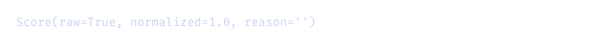

In [ ]:
from lmeh.execution import score_metric

scoring = score_metric(trial=trial, metric=correctness)
scoring.score

For the sake of playing, we could also make an LLM Judge that evaluates the same and gives a brief explanation. You can use the default one or create one that adheres to the `LLMJudgeScorer` protocol.

In [ ]:
from lmeh.datatypes import JudgeConfig
from lmeh.judges import default_llm_judge

judge_config = JudgeConfig(
    model="mistral:mistral-medium-latest",
    generation_kwargs={"temperature": 0.1},
)

correctness_2 = Metric(
    name="correctness2",
    description="whether the answer is correct or not",
    scale=Ordinal(levels=[False, True]),
    scorer=default_llm_judge,
    judge_config=judge_config,
)

Lets evaluate it on the same example and see what the Judge thinks about the system output.

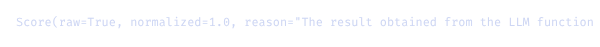

In [ ]:
judge_scoring = score_metric(trial=trial, metric=correctness_2)
judge_scoring.score

Finally, we can make a full run: execute our `detect_hate` target function on all the examples from our dataset and evaluate our two metrics on the outputs.

In [ ]:
from lmeh.execution import run_experiment
from lmeh.datatypes import Experiment

experiment = Experiment(
    name="silly-test",
    target=detect_hate,
    config=config
)

results = run_experiment(
    experiment=experiment,
    dataset=dataset,
    metrics=[correctness, correctness_2],
    workers=5
)

And we can use a reporting utility to see the results.

In [ ]:
from lmeh.reporting import markdown_report
mo.md(markdown_report(results))

<span class="markdown prose dark:prose-invert contents"><h1 id="run-report-silly-test">Run report: <code>silly-test</code></h1>
<span class="paragraph">Summary of one experiment run across the dataset.</span>
<h2 id="experiment">Experiment</h2>
<ul>
<li><strong>Model</strong>: <code>mistral:mistral-small-latest</code></li>
<li><strong>Run timestamp</strong>: 2026-05-18T19:34:43.174226+00:00</li>
</ul>
<h2 id="quality">Quality</h2>
<span class="paragraph">Mean normalized score across every successful scoring (higher is better, in <code>[0, 1]</code>).</span>
<ul>
<li><strong>Mean normalized score</strong>: 0.8000</li>
</ul>
<h3 id="per-metric-mean-normalized-score">Per-metric mean normalized score</h3>
<table>
<thead>
<tr>
<th>Metric</th>
<th>Mean normalized</th>
</tr>
</thead>
<tbody>
<tr>
<td><code>correctness</code></td>
<td>0.8000</td>
</tr>
<tr>
<td><code>correctness2</code></td>
<td>0.8000</td>
</tr>
</tbody>
</table>
<h2 id="reliability">Reliability</h2>
<span class="paragraph">Trial failures count against the run (the target is under evaluation); scorer failures are excluded from quality aggregates.</span>
<ul>
<li><strong>Trials</strong>: 5 successful / 5 total</li>
<li><strong>Trial failure rate</strong>: 0.00%</li>
<li><strong>Scorings</strong>: 10 successful / 10 total</li>
<li><strong>Scoring failure rate</strong>: 0.00%</li>
</ul>
<h2 id="telemetry">Telemetry</h2>
<span class="paragraph">Averages across successful trials only.</span>
<ul>
<li><strong>Mean latency</strong>: 0.844 s</li>
<li><strong>Mean output tokens</strong>: 52.6</li>
<li><strong>Total output tokens</strong>: 263</li>
</ul></span>